## 1. SETUP & IMPORTS

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [2]:
# Configuration
CONFIG = {
    "seed": 42,
    "img_size": 224,   # EfficientNet standard size
    "batch_size": 32,  # Reduce to 16 if you run out of memory
    "epochs": 15,      # Enough to see convergence
    "lr": 1e-4,        # Lower learning rate for fine-tuning
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu")
}

In [3]:
# Set Random Seed for Reproducibility
def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(CONFIG['seed'])
print(f"Using Device: {CONFIG['device']}")

Using Device: cuda


## 2. DATA PREPARATION & HAIR REMOVAL

In [4]:
# Kaggle Paths
BASE_DIR = '/kaggle/input/skin-cancer-mnist-ham10000/'
CSV_PATH = os.path.join(BASE_DIR, 'HAM10000_metadata.csv')
IMG_DIR_1 = os.path.join(BASE_DIR, 'HAM10000_images_part_1')
IMG_DIR_2 = os.path.join(BASE_DIR, 'HAM10000_images_part_2')

In [5]:
# Load Metadata
df = pd.read_csv(CSV_PATH)

In [6]:
# Map Image IDs to Full Paths (Handling both folders)
image_paths = {}
for filename in os.listdir(IMG_DIR_1):
    image_paths[os.path.splitext(filename)[0]] = os.path.join(IMG_DIR_1, filename)
for filename in os.listdir(IMG_DIR_2):
    image_paths[os.path.splitext(filename)[0]] = os.path.join(IMG_DIR_2, filename)

df['path'] = df['image_id'].map(image_paths)

In [7]:
# Encode Labels (0-6)
label_map = {
    'nv': 0, 'mel': 1, 'bkl': 2, 'bcc': 3, 
    'akiec': 4, 'vasc': 5, 'df': 6
}
df['label'] = df['dx'].map(label_map)

In [8]:
# Stratified Split (Crucial for imbalanced data)
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=CONFIG['seed'])

print(f"Training Samples: {len(train_df)}")
print(f"Validation Samples: {len(val_df)}")

Training Samples: 8012
Validation Samples: 2003


In [9]:
# Advanced Hair Removal Function
def remove_hair(image):
    """
    Applies Morphological BlackHat to detect hair and inpaint it.
    Input: OpenCV Image (BGR)
    Output: Cleaned Image (RGB)
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    clean = cv2.inpaint(image, mask, 1, cv2.INPAINT_TELEA)
    return cv2.cvtColor(clean, cv2.COLOR_BGR2RGB)

## 3. CUSTOM DATASET CLASS

In [10]:
class SkinLesionDataset(Dataset):
    def __init__(self, df, transform=None, perform_hair_removal=True):
        self.df = df
        self.transform = transform
        self.perform_hair_removal = perform_hair_removal

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['path']
        label = row['label']
        
        # Read Image
        image = cv2.imread(img_path)
        
        if self.perform_hair_removal:
            image = remove_hair(image) # Returns RGB
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
        # Apply Albumentations
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
            
        return image, torch.tensor(label, dtype=torch.long)

In [11]:
# Transforms (Augmentation for Train, Resize for Val)
train_transforms = A.Compose([
    A.Resize(CONFIG['img_size'], CONFIG['img_size']),
    A.Rotate(limit=30, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transforms = A.Compose([
    A.Resize(CONFIG['img_size'], CONFIG['img_size']),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

In [12]:
# DataLoaders
train_dataset = SkinLesionDataset(train_df, transform=train_transforms, perform_hair_removal=True)
val_dataset = SkinLesionDataset(val_df, transform=val_transforms, perform_hair_removal=True)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=2)

## 4. MODEL & CLASS IMBALANCE HANDLING

In [13]:
# Initialize EfficientNet-B0 (Good balance of speed/accuracy)
model = models.efficientnet_b0(weights='DEFAULT')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 170MB/s]


In [14]:
# Modify the Final Layer for 7 Classes
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, 7)
model = model.to(CONFIG['device'])

In [15]:
# Calculate Class Weights for Loss Function (Handling Imbalance)
# Formula: Max_Count / Count_i (Simple weighting strategy)
class_counts = df['label'].value_counts().sort_index().values
max_count = max(class_counts)
class_weights = torch.tensor([max_count / c for c in class_counts], dtype=torch.float).to(CONFIG['device'])

print("Class Weights:", class_weights)

Class Weights: tensor([ 1.0000,  6.0243,  6.1010, 13.0447, 20.5046, 47.2183, 58.3043],
       device='cuda:0')


In [16]:
# Loss & Optimizer
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=CONFIG['lr'])

## 5. TRAINING LOOP WITH LIVE PLOTTING

In [17]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_acc = 0.0

print("Starting Training...")

for epoch in range(CONFIG['epochs']):
    # --- Training Phase ---
    model.train()
    train_loss = 0
    correct = 0
    total = 0
    
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONFIG['epochs']} [Train]", leave=False)
    for images, labels in loop:
        images, labels = images.to(CONFIG['device']), labels.to(CONFIG['device'])
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Update progress bar
        loop.set_postfix(loss=loss.item())

    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = correct / total
    
    # --- Validation Phase ---
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(CONFIG['device']), labels.to(CONFIG['device'])
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = correct / total
    
    # Store history
    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(avg_train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(avg_val_acc)
    
    print(f"Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Train Acc={avg_train_acc:.4f} | Val Loss={avg_val_loss:.4f}, Val Acc={avg_val_acc:.4f}")
    
    # Save Best Model
    if avg_val_acc > best_acc:
        best_acc = avg_val_acc
        torch.save(model.state_dict(), "best_skin_model.pth")

print("Training Complete!")

Starting Training...


Epoch 1/15 [Train]:   0%|          | 0/251 [00:00<?, ?it/s]

Epoch 1: Train Loss=1.5132, Train Acc=0.5175 | Val Loss=0.9913, Val Acc=0.6350


Epoch 2/15 [Train]:   0%|          | 0/251 [00:00<?, ?it/s]

Epoch 2: Train Loss=1.0211, Train Acc=0.6435 | Val Loss=0.7776, Val Acc=0.6980


...

Epoch 13: Train Loss=0.3770, Train Acc=0.8119 | Val Loss=0.6060, Val Acc=0.8038


Epoch 14/15 [Train]:   0%|          | 0/251 [00:00<?, ?it/s]

Epoch 14: Train Loss=0.3993, Train Acc=0.8148 | Val Loss=0.6420, Val Acc=0.8013


Epoch 15/15 [Train]:   0%|          | 0/251 [00:00<?, ?it/s]

Epoch 15: Train Loss=0.3553, Train Acc=0.8193 | Val Loss=0.7492, Val Acc=0.8083
Training Complete!


## 6. VISUALIZATION & EVALUATION

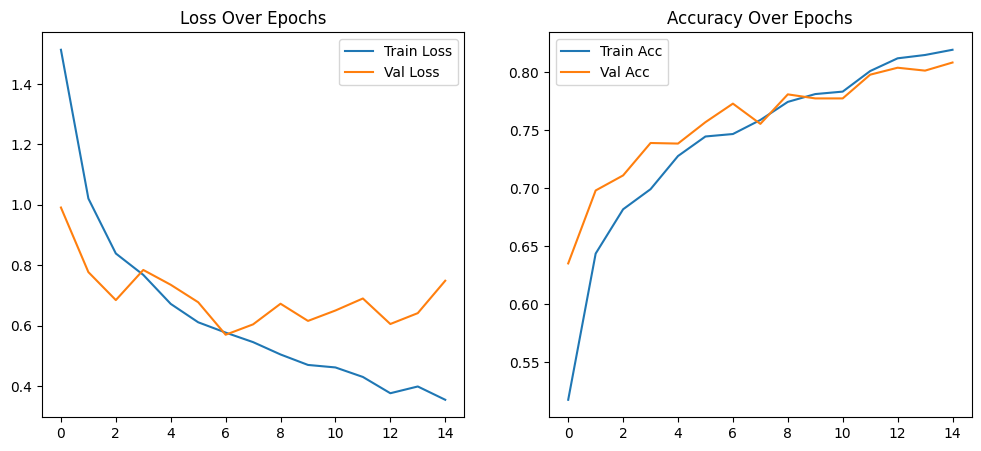

In [18]:
# Plot Training Curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy Over Epochs')
plt.legend()
plt.show()

In [19]:
# Final Classification Report
print("\nGenerating Final Evaluation Report...")
model.load_state_dict(torch.load("best_skin_model.pth"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Evaluating"):
        images, labels = images.to(CONFIG['device']), labels.to(CONFIG['device'])
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


Generating Final Evaluation Report...


Evaluating:   0%|          | 0/63 [00:00<?, ?it/s]

In [20]:
# Print detailed Metrics
class_names = list(label_map.keys())
print(classification_report(all_labels, all_preds, target_names=class_names))

              precision    recall  f1-score   support

          nv       0.96      0.84      0.90      1341
         mel       0.49      0.78      0.60       223
         bkl       0.69      0.68      0.68       220
         bcc       0.70      0.80      0.75       103
       akiec       0.62      0.71      0.66        65
        vasc       0.75      0.86      0.80        28
          df       0.52      0.48      0.50        23

    accuracy                           0.81      2003
   macro avg       0.68      0.74      0.70      2003
weighted avg       0.84      0.81      0.82      2003



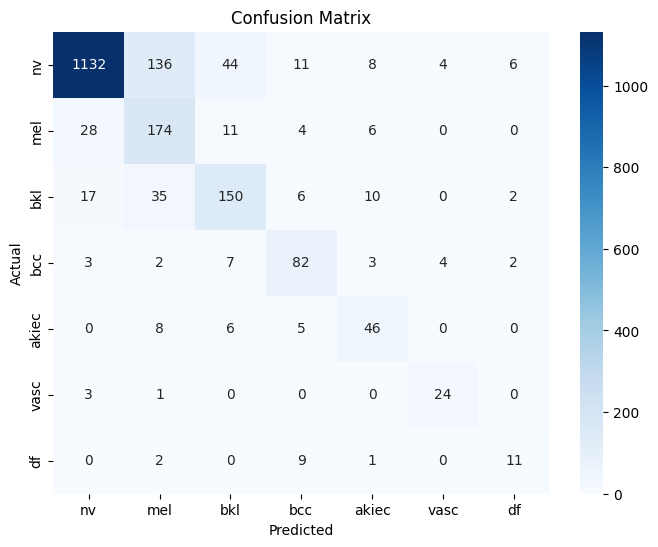

In [21]:
# Plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 7. EXPORT TO ONNX (For Local Deployment)

In [22]:
dummy_input = torch.randn(1, 3, 224, 224).to(CONFIG['device'])
onnx_path = "derma_model.onnx"
torch.onnx.export(model, dummy_input, onnx_path, 
                  input_names=['input'], output_names=['output'], 
                  dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}})

print(f"Model exported to {onnx_path}. Please download this file for your backend.")

Model exported to derma_model.onnx. Please download this file for your backend.
